****
**1. Install Required Libraries**
****

In [1]:
!pip install tensorflow matplotlib scikit-learn


****
**2. Mount Google Drive**
****

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


****
**3. Define Dataset Paths**
****

In [3]:
TRAIN_DIR = '/content/drive/MyDrive/chest-xray-pneumonia-detection/Dataset/chest_xray/train'
TEST_DIR  = '/content/drive/MyDrive/chest-xray-pneumonia-detection/Dataset/chest_xray/test'
VAL_DIR   = '/content/drive/MyDrive/chest-xray-pneumonia-detection/Dataset/chest_xray/val'

****
**4. Verify Dataset Structure**
****

In [4]:
import os
print(os.path.exists(TRAIN_DIR))
print(os.path.exists(TEST_DIR))
print(os.listdir(TRAIN_DIR))

True
True
['NORMAL', 'PNEUMONIA']


****
**5. Create a Sample Dataset of 50 Images**
****

In [5]:

import os
import shutil
import random

DATASET_SIZE = 1000   # Change to 200, 500, 700, 1000 later

SOURCE_TRAIN = "/content/drive/MyDrive/chest-xray-pneumonia-detection/Dataset/chest_xray/train"
TARGET = "/content/sample_dataset"

if os.path.exists(TARGET):
    shutil.rmtree(TARGET)

os.makedirs(f"{TARGET}/NORMAL")
os.makedirs(f"{TARGET}/PNEUMONIA")

normal_count = DATASET_SIZE // 2
pneumonia_count = DATASET_SIZE // 2

normal_images = os.listdir(f"{SOURCE_TRAIN}/NORMAL")
pneumonia_images = os.listdir(f"{SOURCE_TRAIN}/PNEUMONIA")

selected_normal = random.sample(normal_images, normal_count)
selected_pneumonia = random.sample(pneumonia_images, pneumonia_count)

for img in selected_normal:
    shutil.copy(
        f"{SOURCE_TRAIN}/NORMAL/{img}",
        f"{TARGET}/NORMAL/{img}"
    )

for img in selected_pneumonia:
    shutil.copy(
        f"{SOURCE_TRAIN}/PNEUMONIA/{img}",
        f"{TARGET}/PNEUMONIA/{img}"
    )

print(f"Dataset created with {DATASET_SIZE} images")


Dataset created with 1000 images


****
**6. Verify Sample Dataset**
****


In [6]:
import os

print("NORMAL:", len(os.listdir("/content/sample_dataset/NORMAL")))
print("PNEUMONIA:", len(os.listdir("/content/sample_dataset/PNEUMONIA")))

NORMAL: 500
PNEUMONIA: 500


****
**7. Load Dataset**
****


In [8]:
import tensorflow as tf

IMG_SIZE = (224,224)
BATCH_SIZE = 16


train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/sample_dataset",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/sample_dataset",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 1000 files belonging to 2 classes.
Using 800 files for training.
Found 1000 files belonging to 2 classes.
Using 200 files for validation.


****
**Check Dataset Size**
****

In [9]:
print("Training batches:", len(train_ds))
print("Testing batches:", len(test_ds))

Training batches: 50
Testing batches: 13


****
**9. Build MobileNetV2 Model**
****


In [10]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(128, activation='relu'),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

****
**10. Compile Model**
****


In [11]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

****
**11. Train Model**
****


In [12]:
import time

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

start_time = time.time()

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=8,
    callbacks=[early_stop]
)

end_time = time.time()

training_time = end_time - start_time

print("Training Time:", round(training_time,2), "seconds")

Epoch 1/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 44s 505ms/step - accuracy: 0.6812 - loss: 0.6158 - val_accuracy: 0.9000 - val_loss: 0.3259
Epoch 2/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 240ms/step - accuracy: 0.8450 - loss: 0.3486 - val_accuracy: 0.9250 - val_loss: 0.2416
Epoch 3/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 170ms/step - accuracy: 0.8938 - loss: 0.2705 - val_accuracy: 0.9250 - val_loss: 0.2133
Epoch 4/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 150ms/step - accuracy: 0.8900 - loss: 0.2526 - val_accuracy: 0.9250 - val_loss: 0.1991
Epoch 5/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 192ms/step - accuracy: 0.9175 - loss: 0.2141 - val_accuracy: 0.9300 - val_loss: 0.1903
Epoch 6/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 155ms/step - accuracy: 0.9250 - loss: 0.2109 - val_accuracy: 0.9350 - val_loss: 0.1807
Epoch 7/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 149ms/step - accuracy: 0.9225 - loss: 0.2004 - val_accuracy: 0.9300 - val_loss: 0.1725
Epoch 8/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 191ms/step - accuracy: 0.9212 - loss: 0.1994 - val_accuracy: 0.945

****
**12. Evaluate Model**
****


In [13]:

loss, accuracy = model.evaluate(test_ds)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

print("\n----- RESULTS -----")
print("Model Name: MobileNetV2")
print("Dataset Size:", DATASET_SIZE)
print("Training Time:", round(training_time,2), "seconds")
print("Accuracy:", round(float(accuracy),4))
print("Loss:", round(float(loss),4))


13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 122ms/step - accuracy: 0.9450 - loss: 0.1639
Test Loss: 0.16393320262432098
Test Accuracy: 0.9449999928474426

----- RESULTS -----
Model Name: MobileNetV2
Dataset Size: 1000
Training Time: 110.11 seconds
Accuracy: 0.945
Loss: 0.1639


****
**13. Accuracy Graph**
****


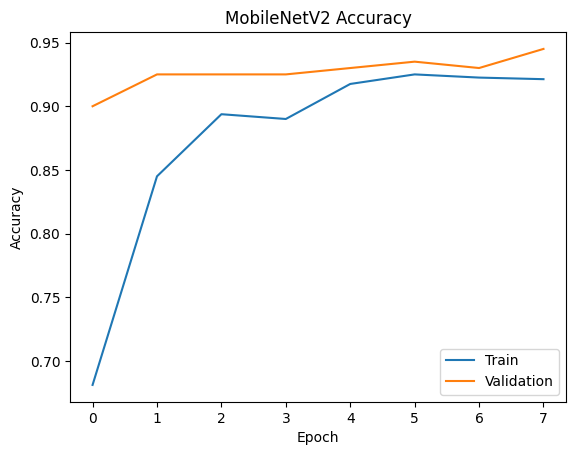

In [14]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('MobileNetV2 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

plt.show()

****
**14. Loss Graph**
****

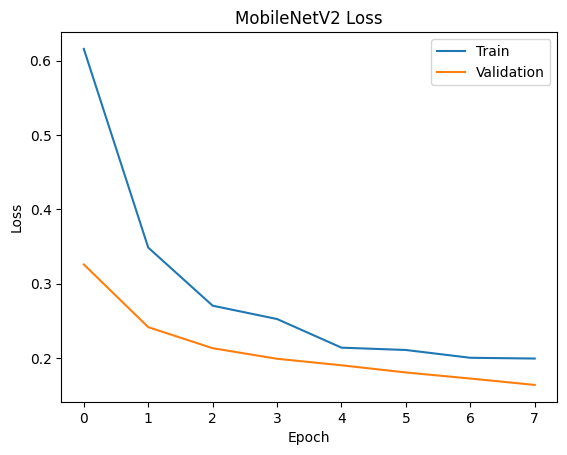

In [15]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('MobileNetV2 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])

plt.show()

****
**15. Save the Model**
****

In [16]:
model.save("mobilenetv2_pneumonia_model.keras")

print("Model saved successfully!")

Model saved successfully!


In [17]:
from google.colab import files

files.download("mobilenetv2_pneumonia_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>